In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import sympy
import random

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
df = pd.read_pickle('/home/paolo/Na_dataset/diffusion.pckl.gzip', compression='gzip')

In [3]:
df

,structure,atoms,D_sim,D_300K,Ea,D0,r,D_sim_std,atoms_diffusion,diffusion_temps,...,VPA,NBI,RBI,weighted_electronegativity,FV,Na_spacing,Na_former_ratio,Na_anion_ratio,log_conductivity,logD
0,"[[-40.55755644 -31.11690268 -12.78408373] Na, ...","(Atom('Na', [-40.557556437030854, -31.11690267...","[1.4364625631071203e-07, 1.951308390440328e-06...",0.0,0.41481,-6.168029,-0.999534,"[2.0609274977491014e-08, 9.54751980775219e-08,...","[(Atom('Na', [16.4013, 25.9231, 16.2528], mome...","[500, 700, 900, 1100]",...,30.092044,0.672310,3.270586,2.779514,16.271870,5.009553,0.818182,0.239362,-6.802830,-22.213615
1,"[[-27.22272146 -48.08938883 -1.16173696] Na, ...","(Atom('Na', [-27.222721459416434, -48.08938883...","[5.260053344200803e-08, 4.0005952618958283e-07...",0.0,0.342211,-8.892149,-0.998229,"[1.170380927951024e-08, 3.5028882907097395e-08...","[(Atom('Na', [22.3934, 1.16212, 24.5241], mome...","[500, 700, 900, 1100]",...,28.802260,0.534658,1.160079,2.334804,9.578810,4.023160,0.851852,0.442308,-6.060846,-22.129469
2,"[[ -8.75124573 -35.84817417 1.41113688] Na, ...","(Atom('Na', [-8.751245728991412, -35.848174165...","[4.1491531541234836e-07, 2.9527838854461532e-0...",0.0,0.309818,-7.538836,-0.999465,"[4.712111654890927e-08, 1.5290730622277523e-07...","[(Atom('Na', [21.1725, 23.88, 1.00372], moment...","[500, 700, 900, 1100]",...,41.988188,0.418590,3.717974,2.110441,16.853349,4.911786,0.818182,0.387931,-4.053234,-19.523147
3,"[[ 5.90065301 -22.92956849 38.91278713] Na, ...","(Atom('Na', [5.900653007410151, -22.9295684907...","[3.644390884127098e-07, 2.282692400171146e-06,...",0.0,0.336138,-7.142088,-0.995077,"[2.3186241807603783e-08, 7.300603522025543e-08...","[(Atom('Na', [6.08525, 5.03001, 8.8188], momen...","[500, 700, 900, 1100]",...,44.180268,0.459960,12.327698,1.925347,13.252481,3.934283,2.846154,0.725490,-4.008862,-20.144502
4,"[[-19.7964428 -12.94618545 -22.08417706] Na, ...","(Atom('Na', [-19.79644280037215, -12.946185446...","[6.07698230883191e-08, 2.0869815246937256e-07,...",0.0,0.364908,-8.508542,-0.964053,"[1.548478587054459e-08, 3.1640692055019905e-08...","[(Atom('Na', [3.56707, 11.3108, 1.84764], mome...","[500, 700, 900, 1100]",...,21.846223,0.603340,1.635307,2.640404,9.327898,4.334335,0.492537,0.268293,-6.778690,-22.623812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,"[[-45.16852818 -78.13919154 20.16465523] Na, ...","(Atom('Na', [-45.16852817712178, -78.139191541...","[3.297906167882209e-06, 1.8844573960753516e-05...",0.0,0.247734,-6.836898,-0.999179,"[9.792967224616881e-08, 3.9756638417401317e-07...","[(Atom('Na', [21.5008, 25.8636, 21.0757], mome...","[500, 700, 900, 1100]",...,51.279798,0.503579,9.309462,2.179317,22.017312,4.934985,1.828571,0.426667,-0.963887,-16.419663
1300,"[[ 27.78664333 -31.36783786 -24.2354884 ] Na, ...","(Atom('Na', [27.786643333402175, -31.367837857...","[9.156914520012137e-07, 5.1272087089512735e-06...",0.0,0.283584,-7.370918,-0.998882,"[4.870329640437488e-08, 1.4125831290277235e-07...","[(Atom('Na', [-1.42491, -1.18625, 5.80358], mo...","[500, 700, 900, 1100]",...,47.672488,0.587851,2.941818,2.144747,15.234442,3.981873,2.846154,0.755102,-2.240883,-18.340452
1301,"[[ 9.75765064 -22.01865729 14.7129202 ] Na, ...","(Atom('Na', [9.757650639408531, -22.0186572933...","[1.8383356363262403e-07, 1.3151544777712655e-0...",0.0,0.326622,-7.991634,-0.998646,"[1.634566553839534e-08, 5.978999364457793e-08,...","[(Atom('Na', [10.255, 6.08899, 15.3406], momen...","[500, 700, 900, 1100]",...,42.832632,0.457983,1.896230,1.958541,11.402734,3.826133,1.857143,0.764706,-4.406686,-20.625948
1302,"[[-39.37930038 -62.24010789 -38.49384248] Na, ...","(Atom('Na', [-39.37930038383808, -62.240107891...","[8.887014627167615e-07, 6.4231800149440465e-06...",0.0,0.297862,-7.015121,-0.999876,"[4.980311200542334e-08, 2.1804315739470145e-07...","[(Atom('Na', [22.5873, 0.0336273, 22.6647], mo...","[500, 700, 900, 1100]",...,39.816525,0.617591,3.275683,2.479636,17.560774,4.69335

In [4]:
df.columns

Index(['structure', 'atoms', 'D_sim', 'D_300K', 'Ea', 'D0', 'r', 'D_sim_std',
       'atoms_diffusion', 'diffusion_temps', 'formula', 'composition', 'B%',
       'N%', 'O%', 'F%', 'Na%', 'Al%', 'Si%', 'P%', 'S%', 'Cl%', 'Ge%', 'Br%',
       'I%', 'density', 'AAV', 'PF', 'SBI', 'VPA', 'NBI', 'RBI',
       'weighted_electronegativity', 'FV', 'Na_spacing', 'Na_former_ratio',
       'Na_anion_ratio', 'log_conductivity', 'logD'],
      dtype='object')

In [5]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
kb

8.617333262e-05

In [39]:
np.median(ln_D)

-15.02083620706173

(array([  2.,   4.,  11.,  54., 164., 200., 253., 322., 225.,  67.]),
 array([-14.43083927, -13.8733844 , -13.31592953, -12.75847466,
        -12.2010198 , -11.64356493, -11.08611006, -10.52865519,
         -9.97120032,  -9.41374546,  -8.85629059]),
 <BarContainer object of 10 artists>)

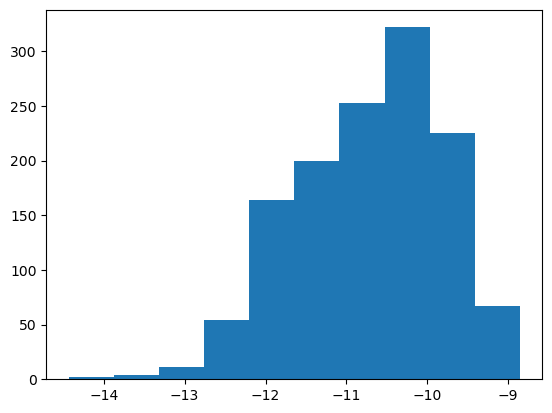

In [57]:
plt.hist(ln_D)

To avoid an excessive statistical weight we remove systems with small diffusivity, i.e. with ln(D)<-15.

In [207]:
def initialize(i, med_flag = False):
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    ln_D_all = np.log(np.array(df['D_sim'].str[i]))
    if (med_flag == True):
        med =  np.median(ln_D_all).round()
        ln_D = ln_D_all[ln_D_all>med]
        ind = np.where(ln_D_all > med)[0]
    else:
        med = -15
        ln_D = ln_D_all[ln_D_all>-15]
        ind = np.where(ln_D_all > -15)[0]
    T = np.array(df['diffusion_temps'].str[i])[ind]
    
    return {
        "ln_D_all" : ln_D_all,
        "ln_D" : ln_D,
        "T" : T,
        "E" : np.array(df['Ea'], dtype = 'float')[ind]/(kb*T),
        "ln_D0" : np.array(df['D0'], dtype = 'float')[ind],
        "med" : med, 
        
        # Atomic fractions of a given element
        "B":  np.array(df['B%'], dtype='float')[ind],
        "N":  np.array(df['N%'], dtype='float')[ind],
        "O":  np.array(df['O%'], dtype='float')[ind],
        "F":  np.array(df['F%'], dtype='float')[ind],
        "Na": np.array(df['Na%'], dtype='float')[ind],
        "Al": np.array(df['Al%'], dtype='float')[ind],
        "Si": np.array(df['Si%'], dtype='float')[ind],
        "P":  np.array(df['P%'], dtype='float')[ind],
        "S":  np.array(df['S%'], dtype='float')[ind],
        "Cl": np.array(df['Cl%'], dtype='float')[ind],
        "Ge": np.array(df['Ge%'], dtype='float')[ind],
        "Br": np.array(df['Br%'], dtype='float')[ind],
        "I":  np.array(df['I%'], dtype='float')[ind],
        
        "density": np.array(df['density'], dtype='float')[ind],
        # Average Atomic Volume
        "AAV": np.array(df['AAV'], dtype='float')[ind],
        # Packing fraction
        "PF": np.array(df['PF'], dtype='float')[ind],
        # set-of-non-Na-atoms bond ionicity
        "SBI": np.array(df['SBI'], dtype='float')[ind],
        # Volume per anion
        "VPA": np.array(df['VPA'], dtype='float')[ind],
        # Na bond ionicity
        "NBI": np.array(df['NBI'], dtype='float')[ind],
        # Ratio of NBI and SBI
        "RBI": np.array(df['RBI'], dtype='float')[ind],
        # Weighted electronegativity
        "WE": np.array(df['weighted_electronegativity'], dtype='float')[ind],
    }

In [196]:
data = initialize(1)
data['E'].size

1241

In [197]:
data = initialize(1, med_flag = True)
data['E'].size

707

In [223]:
i = 3
data = initialize(i, med_flag = True)
med = data['med']
lnDvsE = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data['ln_D']))], 
    "E_T": data['E'],
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data['PF'],
    "VPA": data['VPA'],
    "RBI": data['RBI'],
    "WE": data['WE'],
    "B": data['B'],
    "N": data['N'],
    "S": data['S'],
    "O": data['O'],
    "F": data['F'],
    "Na": data['Na'],
    "Al": data['Al'],
    "Si": data['Si'],
    "P": data['P'],
    "Cl": data['Cl'],
    "Ge": data['Ge'],
    "Br": data['Br'],
    "I": data['I'],
    "ln_D": data['ln_D']
})

In [224]:
np.median(data['ln_D_all']), med

(-10.592180931278568, -11.0)

In [191]:
#data['ln_D'] > med

In [ ]:
# NBI and SBI were excluded because RBI is a ratio of the two

In [225]:
n_feat = 20
lnDvsE.to_csv(f"/home/paolo/Thesis/Na/data/Na_lndiff{n_feat}_temp{i}_pruned{med}.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/Na_lndiff{n_feat}_temp{i}_pruned{med}.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [226]:
# Try the fit with the exact functional form
rung = 2
Diff_json = {
    'data_file': data_file,
     'property_key': 'ln_D',
     'desc_dim': 1,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/lndiff{n_feat}_{rung}_temp{i}_pruned{med}.json", "w"), indent=4)

In [ ]:
# Rung=2 Features=3, Time=instant 'E_T': E, 'AAV': AAV, 'rho': density
# c0 + a0 * ((AAV - E/T) - (rho + E/T))
# Property Label: $ln_{D}$; Unit of the Property: Unitless
# RMSE: 0.43153770171928; Max AE: 1.37649484674825
# Coefficients
# Task   a0                      c0
# all ,  1.720847461812097e-01, -1.554720987752086e+01, 

In [ ]:
# Rung=2 Features=6, Time=instant 'E_T': E, 'AAV': AAV, 'VPA': VPA, 'PF': PF, 'rho': density, 'NBI': NBI
# time input_parsing: 0.0122288 s
# Time to generate feat space: 0.0953456 s
# Projection time: 0.0042624 s
# Time to get best features on rank : 5.75e-05 s
# |---Complete final combination/selection from all ranks: 0.0006845 s
# Time for SIS: 0.0064293 s
# Time for l0-norm: 0.0100492 s
# Train RMSE: 0.419018 Unitless
# c0 + a0 * ((AAV - E_T) - (rho / NBI))

# c0 + a0 * ((AAV - E_T) - (rho / NBI))
# Property Label: $ln_{D}$; Unit of the Property: Unitless
# RMSE: 0.419017832368958; Max AE: 1.21935407313866
# Coefficients
# Task   a0                      c0
# all ,  2.105810962152558e-01, -1.684379252614514e+01, 

In [ ]:
# Adding the Atomic fractions

In [ ]:
# Rung=2 Features=8, Time=instant 'E_T': E, 'AAV': AAV, 'VPA': VPA, 'PF': PF, 'rho': density, 'NBI': NBI, 'S': S, 'O': O
# time input_parsing: 0.010877 s
# Time to generate feat space: 0.23877 s
# Projection time: 0.0106349 s
# Time to get best features on rank : 5.83e-05 s
# |---Complete final combination/selection from all ranks: 0.0003374 s
# Time for SIS: 0.0142641 s
# Time for l0-norm: 0.0165753 s
# Train RMSE: 0.41694 Unitless
# c0 + a0 * ((AAV / E_T) - (O + PF))

# c0 + a0 * ((AAV / E_T) - (O + PF))
# Property Label: $ln_{D}$; Unit of the Property: Unitless
# RMSE: 0.416939842796493; Max AE: 1.45271349362396
# Coefficients
# Task   a0                      c0
# all ,  9.359544285973778e-01, -1.705449815622026e+01, 

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# time input_parsing: 0.0211895 s
# Time to generate feat space: 6.45117 s
# Projection time: 0.210544 s
# Time to get best features on rank : 7.28e-05 s
# |---Complete final combination/selection from all ranks: 0.0004383 s
# Time for SIS: 0.311242 s
# Time for l0-norm: 0.0026668 s
# Train RMSE: 0.41275 Unitless
# c0 + a0 * ((AAV - E_T) * (B + WE))

# c0 + a0 * ((AAV - E_T) * (B + WE))
# Property Label: $ln_{D}$; Unit of the Property: Unitless
# RMSE: 0.4127503954523; Max AE: 1.63251473515629
# Coefficients
# Task   a0                      c0
# all ,  8.938019183393937e-02, -1.771178974412554e+01,

In [ ]:
c0 + a0*AAV*B + a0*AAV*WE - a0*(B+WE)*E/(kb*T)

In [116]:
# c0 = -1.771178974412554e+01
# a0 = 8.938019183393937e-02
# fct = c0 + a0 * ((AAV - E) * (B + WE))
# # plt.scatter(E , ln_D, alpha = 0.5, color = 'orange', label = 'D_sim vs E train')
# # plt.scatter(E, fct)
# plt.scatter(fct, ln_D)
# plt.plot([-15,-12], [-15, -12], color = 'red')
# plt.show()

In [10]:
E0 = []
t_range = [500, 700, 900, 1100]
for t in t_range:
    E0.append(np.array(df['Ea'], dtype = 'float')[0]/(kb*t))
E0

[9.627351630837904, 6.876679736312789, 5.348528683798835, 4.376068923108138]

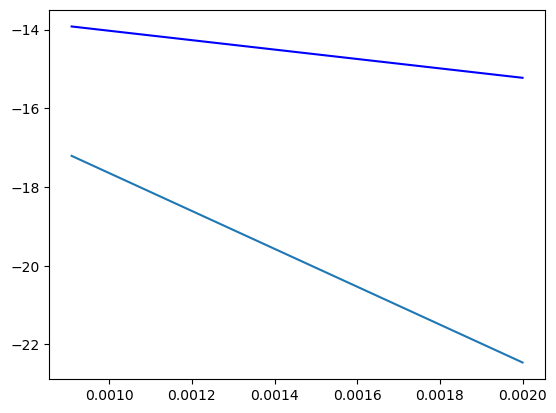

In [20]:
c0 = -1.771178974412554e+01
a0 = 8.938019183393937e-02
fct = c0 + a0*AAV[0]*B[0] + a0*AAV[0]*WE[0] - a0*(B[0]+WE[0])*np.array(E0)
ideal = c0 + a0*AAV[0]*B[0] + a0*AAV[0]*WE[0] - np.array(E0)
plt.plot(1/np.array(t_range), fct, color = 'blue')
plt.plot(1/np.array(t_range), ideal)

In [ ]:
# Rung=3 Features=4 'E_T': E, 'AAV': AAV, 'VPA': VPA, 'rho': density
# time input_parsing: 0.0072777 s
# Time to generate feat space: 214.484 s
# Projection time: 5.34174 s
# Time to get best features on rank : 0.0036932 s
# |---Complete final combination/selection from all ranks: 0.0082582 s
# Time for SIS: 9.76598 s
# Time for l0-norm: 0.0100359 s


# c0 + a0 * (((rho + E/T) + (rho - AAV)) / ((VPA / rho) + (VPA * E/T)))
# Property Label: $ln_{D}$; Unit of the Property: Unitless
# RMSE: 0.381405821223442; Max AE: 1.49718898209431
# Coefficients
# Task   a0                      c0
# all , -6.198024426835201e+01, -1.664497489880065e+01, 

In [29]:
# Rung=3 Features=5 'E_T': E, 'AAV': AAV, 'VPA': VPA, 'PF': PF, 'rho': density
# time input_parsing: 0.0076366 s
# Time to generate feat space: 208.59 s
# Projection time: 5.48175 s
# Time to get best features on rank : 8.7e-05 s
# |---Complete final combination/selection from all ranks: 0.0115689 s
# Time for SIS: 9.86845 s
# Time for l0-norm: 0.0302483 s

# c0 + a0 * (((rho + E/T) + (rho - AAV)) / ((VPA / rho) + (VPA * E/T)))
# Property Label: $ln_{D}$; Unit of the Property: Unitless
# RMSE: 0.381405821223442; Max AE: 1.49718898209431
# Coefficients
# Task   a0                      c0
# all , -6.198024426835201e+01, -1.664497489880065e+01, 

In [ ]:
# Rung=3 Features=6 'E_T': E, 'AAV': AAV, 'VPA': VPA, 'PF': PF, 'rho': density, 'NBI': NBI
# Segmentation fault (core dumped)
# Error too high dimension

# Removing low diffusivity systems

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 500;       Pruned of low diff syst

# time input_parsing: 0.0258523 s
# Time to generate feat space: 6.41681 s
# Projection time: 0.266922 s
# Time to get best features on rank : 8.35e-05 s
# |---Complete final combination/selection from all ranks: 0.0010931 s
# Time for SIS: 0.363487 s
# Time for l0-norm: 0.0077255 s
# Train RMSE: 0.28559 Unitless
# c0 + a0 * ((O - WE) * (AAV / E_T))
# Coefficients
# Task   a0                      c0
# all , -3.170577930179694e-01, -1.645555138803230e+01, 

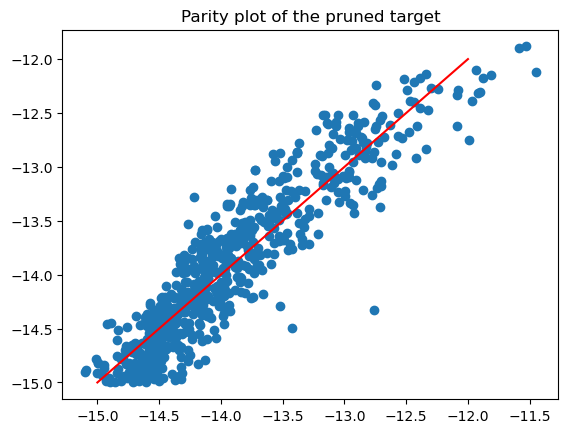

In [154]:
plt.title('Parity plot of the pruned target')
data = initialize(0)
a0 = -3.170577930179694e-01                      
c0 = -1.645555138803230e+01
fct = c0 + a0 * ((data['O'] - data['WE']) * (data['AAV'] / data['E']))
# plt.scatter(E , ln_D, alpha = 0.5, color = 'orange', label = 'D_sim vs E train')
# plt.scatter(E, fct)
plt.scatter(fct, data['ln_D'])
plt.plot([-15,-12], [-15, -12], color = 'red')
plt.show()

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 700;       ln(D)>-15
# time input_parsing: 0.0391739 s
# Time to generate feat space: 7.06266 s
# Projection time: 0.467516 s
# Time to get best features on rank : 0.0001252 s
# |---Complete final combination/selection from all ranks: 0.0003604 s
# Time for SIS: 0.566161 s
# Time for l0-norm: 0.008758 s
# Train RMSE: 0.435971 Unitless
# c0 + a0 * ((WE * AAV) / exp(O))
# Coefficients
# Task   a0                      c0
# all ,  6.693823019157683e-02, -1.570700580955622e+01, 

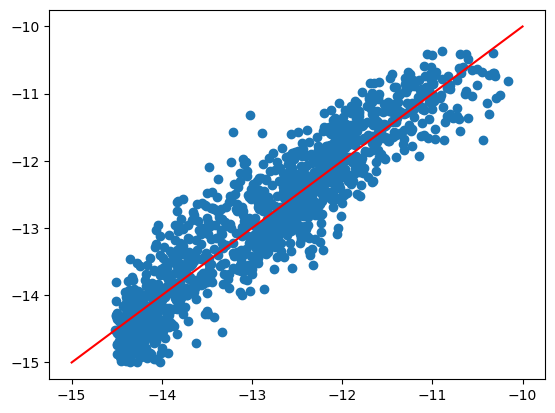

In [156]:
a0 = 6.693823019157683e-02                     
c0 = -1.570700580955622e+01
data = initialize(1)
fct = c0 + a0 * ((data['WE'] * data['AAV']) / np.exp(data['O']))
plt.scatter(fct, data['ln_D'])
plt.plot([-15,-10], [-15, -10], color = 'red')
plt.show()

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 900;       Pruned of low diff syst ln(D)>-15
# time input_parsing: 0.0405476 s
# Time to generate feat space: 6.99426 s
# Projection time: 0.483386 s
# Time to get best features on rank : 0.0001668 s
# |---Complete final combination/selection from all ranks: 0.0003523 s
# Time for SIS: 0.583194 s
# Time for l0-norm: 0.0072303 s
# Train RMSE: 0.416518 Unitless
# c0 + a0 * ((WE * AAV) / exp(O))
# Coefficients
# Task   a0                      c0
# all ,  5.916901550023317e-02, -1.405689341845803e+01, 

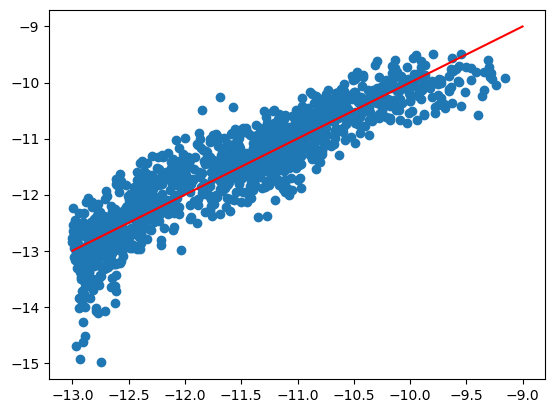

In [160]:
a0 = 5.916901550023317e-02                     
c0 = -1.405689341845803e+01
data = initialize(2)
fct = c0 + a0 * ((data['WE'] * data['AAV']) / np.exp(data['O']))
plt.scatter(fct, data['ln_D'])
plt.plot([-13,-9], [-13, -9], color = 'red')
plt.show()

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 1100;       Pruned of low diff syst ln(D)>-15
# time input_parsing: 0.0377638 s
# Time to generate feat space: 7.06443 s
# Projection time: 0.513853 s
# Time to get best features on rank : 0.0001667 s
# |---Complete final combination/selection from all ranks: 0.0003532 s
# Time for SIS: 0.619801 s
# Time for l0-norm: 0.0049558 s
# Train RMSE: 0.358855 Unitless
# c0 + a0 * ((O / RBI) - (AAV / VPA))
# Coefficients
# Task   a0                      c0
# all , -5.763219908420919e+00, -1.339747228159673e+01, 

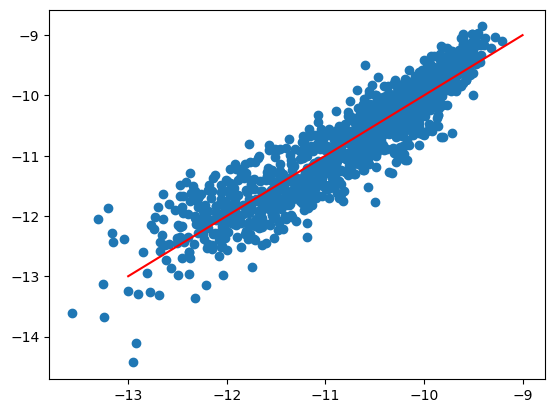

In [161]:
a0 = -5.763219908420919e+00                    
c0 = -1.339747228159673e+01
data = initialize(3)
fct = c0 + a0 * ((data['O'] / data['RBI']) - (data['AAV'] / data['VPA']))
plt.scatter(fct, data['ln_D'])
plt.plot([-13,-9], [-13, -9], color = 'red')
plt.show()

# Median pruning

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 500;       ln(D)>-15

# time input_parsing: 0.0258523 s
# Time to generate feat space: 6.41681 s
# Projection time: 0.266922 s
# Time to get best features on rank : 8.35e-05 s
# |---Complete final combination/selection from all ranks: 0.0010931 s
# Time for SIS: 0.363487 s
# Time for l0-norm: 0.0077255 s
# Train RMSE: 0.28559 Unitless
# c0 + a0 * ((O - WE) * (AAV / E_T))
# Coefficients
# Task   a0                      c0
# all , -3.170577930179694e-01, -1.645555138803230e+01, 

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 700;       ln(D)>-13
# time input_parsing: 0.0227874 s
# Time to generate feat space: 6.3757 s
# Projection time: 0.268931 s
# Time to get best features on rank : 8.97e-05 s
# |---Complete final combination/selection from all ranks: 0.0003067 s
# Time for SIS: 0.368885 s
# Time for l0-norm: 0.0038109 s
# Train RMSE: 0.342311 Unitless
# c0 + a0 * ((AAV - E_T) * (B + WE))
# Coefficients
# Task   a0                      c0
# all ,  5.899401259587825e-02, -1.466471894801872e+01, 

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 900;       ln(D)>-11
# Time to generate feat space: 5.73064 s
# Projection time: 0.162762 s
# Time to get best features on rank : 6.74e-05 s
# |---Complete final combination/selection from all ranks: 0.0003088 s
# Time for SIS: 0.24746 s
# Time for l0-norm: 0.0051684 s
# Train RMSE: 0.218862 Unitless
# c0 + a0 * ((AAV / E_T) / (Si + PF))
# Coefficients
# Task   a0                      c0
# all ,  3.606496092710000e-02, -1.122330287704701e+01,

In [ ]:
# Rung=2 Features=20,  'E_T': E, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 1100;       ln(D)>-11
# time input_parsing: 0.0251787 s
# Time to generate feat space: 6.61245 s
# Projection time: 0.329991 s
# Time to get best features on rank : 9.36e-05 s
# |---Complete final combination/selection from all ranks: 0.0003126 s
# Time for SIS: 0.428474 s
# Time for l0-norm: 0.0065326 s
# Train RMSE: 0.243823 Unitless
# c0 + a0 * ((O - WE) * (RBI + AAV))
# Coefficients
# Task   a0                      c0
# all , -3.031245735480044e-02, -1.205405998990424e+01,

# Fitting E vs Rest

In [102]:
EvsRest = pd.DataFrame({"sample_id": [f"s{i+1}" for i in range(len(ln_D))], 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O,
                       'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I,
                       'E_T': E}) 

In [103]:
n_feat = 19
EvsRest.to_csv(f"/home/paolo/Thesis/Na/data/Act_en/Na_Ea{n_feat}_temp{i}_pruned.csv", index=False)
data_file_EA = f"/home/paolo/Thesis/Na/data/Act_en/Na_Ea{n_feat}_temp{i}_pruned.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file_EA

In [104]:
# Try the fit with the exact functional form
rung = 2
Diff_json = {
    'data_file': data_file_EA,
     'property_key': 'E_T',
     'desc_dim': 1,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/Act_en/Ea{n_feat}_{rung}_temp{i}_pruned.json", "w"), indent=4)

In [ ]:
# Rung=2 Features=19,  'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# First 500 entries
# time input_parsing: 0.0145778 s
# Time to generate feat space: 4.91766 s
# Projection time: 0.166274 s
# Time to get best features on rank : 9.88e-05 s
# |---Complete final combination/selection from all ranks: 0.0027908 s
# Time for SIS: 0.245579 s
# Time for l0-norm: 0.002791 s
# Train RMSE: 0.771707 Unitless
# c0 + a0 * ((VPA / PF) / (O + S))

# c0 + a0 * ((VPA / PF) / (O + S))
# Property Label: $E_{T}$; Unit of the Property: Unitless
# RMSE: 0.77170657334263; Max AE: 2.80094821839688
# Coefficients
# Task   a0                      c0
# all , -5.932095972732511e-03,  9.146655214447522e+00, 

Pruning the systems

In [ ]:
# Rung=2 Features=19,  'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 500;       Pruned of low diff syst

# time input_parsing: 0.0204278 s
# Time to generate feat space: 5.0616 s
# Projection time: 0.210906 s
# Time to get best features on rank : 0.0001019 s
# |---Complete final combination/selection from all ranks: 0.0003304 s
# Time for SIS: 0.287208 s
# Time for l0-norm: 0.0033088 s
# Train RMSE: 0.642986 Unitless
# c0 + a0 * ((O + PF) + (Ge + S))
# Coefficients
# Task   a0                      c0
# all ,  3.902885050584737e+00,  3.879181287829220e+00, 

In [ ]:
# Rung=2 Features=19,  'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 700;       Pruned of low diff syst
# time input_parsing: 0.0376195 s
# Time to generate feat space: 5.45145 s
# Projection time: 0.358045 s
# Time to get best features on rank : 0.0001426 s
# |---Complete final combination/selection from all ranks: 0.0003253 s
# Time for SIS: 0.433071 s
# Time for l0-norm: 0.0044584 s
# Train RMSE: 0.543978 Unitless
# c0 + a0 * ((I - Ge) - (P + PF))
# Task   a0                      c0
# all , -3.148693482835391e+00,  4.003595178175703e+00,

In [ ]:
# Rung=2 Features=19,  'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 900;       Pruned of low diff syst
# time input_parsing: 0.0394249 s
# Time to generate feat space: 5.69717 s
# Projection time: 0.391893 s
# Time to get best features on rank : 0.0001858 s
# |---Complete final combination/selection from all ranks: 0.0003394 s
# Time for SIS: 0.475547 s
# Time for l0-norm: 0.0083718 s
# Train RMSE: 0.436839 Unitless
# c0 + a0 * ((Ge + PF) - (I - P))
# Coefficients
# Task   a0                      c0
# all ,  2.399228220111549e+00,  3.131204596291143e+00, 

In [ ]:
# Rung=2 Features=19,  'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 
                        # 'Ge': Ge, 'Br': Br, 'I': I
# Temp = 1100;       Pruned of low diff syst
# time input_parsing: 0.0358419 s
# Time to generate feat space: 5.60982 s
# Projection time: 0.400077 s
# Time to get best features on rank : 0.0001878 s
# |---Complete final combination/selection from all ranks: 0.0003341 s
# Time for SIS: 0.47495 s
# Time for l0-norm: 0.0046793 s
# Train RMSE: 0.357829 Unitless
# c0 + a0 * ((Ge + P) - (I - PF))
# Coefficients
# Task   a0                      c0
# all ,  1.963514010356862e+00,  2.561094482000656e+00,

# Fitting ln(D) with three features: E/(kb*T), AAV and density

In [24]:
def opt_funct(AAV, density, E):
    return (-1.554720987752086e+01 + 1.720847461812097e-01*(AAV - density) - 2*1.720847461812097e-01*E)

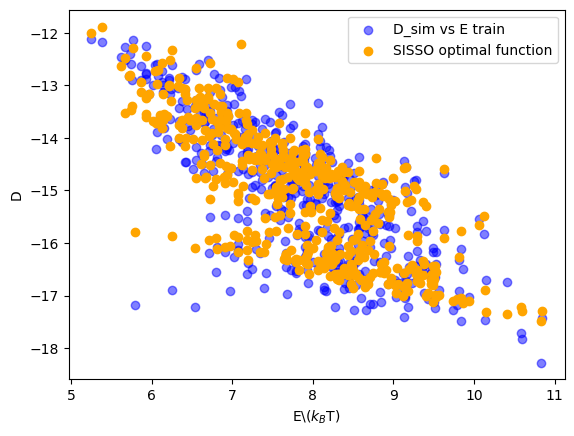

In [38]:
plt.scatter(E , ln_D, alpha = 0.5, color = 'blue', label = 'D_sim vs E train')
plt.scatter(E, opt_funct(AAV, density, E), label='SISSO optimal function', color = 'orange')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.show()

In [35]:
lnD_test = np.log(np.array(df['D_sim'].str[i][600:800]))
T_test = np.array(df['diffusion_temps'].str[i])[600:800]
E_test = np.array(df['Ea'], dtype = 'float')[600:800]/(kb*T_test)
AAV_test = np.array(df['AAV'], dtype = 'float')[600:800]
density_test = np.array(df['density'], dtype = 'float')[600:800]

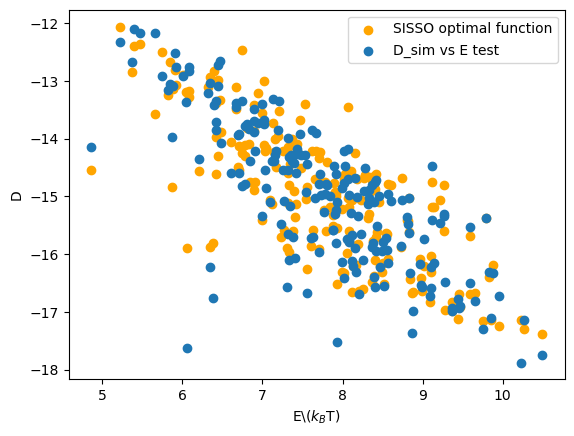

In [39]:
plt.scatter(E_test, opt_funct(AAV_test, density_test, E_test), label='SISSO optimal function', color = 'orange')
plt.scatter(E_test, lnD_test, label = 'D_sim vs E test')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.show()

# PySR

In [8]:
X = lnDvsE.drop(columns=['ln_D','sample_id'])
y = lnDvsE['ln_D']
X

,E_T,AAV,VPA,PF,rho
0,9.627352,19.643418,30.092044,0.300608,2.415193
1,7.942392,14.683505,28.802260,0.568302,2.432141
2,7.190587,23.491189,41.988188,0.357150,2.009418
3,7.801448,22.308848,44.180268,0.520131,2.128812
4,8.469162,12.049711,21.846223,0.418979,2.260671
...,...,...,...,...,...
495,7.479630,24.342565,43.360195,0.387290,2.228466
496,9.121009,11.977043,23.954086,0.601380,2.280671
497,5.870775,28.682391,46.497541,0.257972,1.776821
498,9.939336,13.355947,29.844772,0.892978,2.541803


#outputs/20260102_094621_tyr7UV/hall_of_fame.csv # max_size=30, 5 features, maxdepth = 3
#outputs/20260102_100651_wam1HG/hall_of_fame.csv # max_size=150, 5 features, maxdepth = 3

In [39]:
model3 = PySRRegressor.from_file(
    run_directory="./outputs/20260102_094621_tyr7UV"
)
sympy.simplify(model3.sympy())

Attempting to load model from outputs/20260102_094621_tyr7UV/checkpoint.pkl...


AAV/E_T - 17.825497

In [21]:
model3 = PySRRegressor.from_file(
    run_directory="./outputs/20260102_100651_wam1HG"
)
sympy.simplify(model3.sympy())

Attempting to load model from outputs/20260102_100651_wam1HG/checkpoint.pkl...


AAV/E_T - 17.825445

In [9]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
)

In [19]:
model = PySRRegressor(
    niterations=500,
    populations=50,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["square", "cos", "sin", "exp"],
    maxdepth = 3,
    maxsize = 150
)
model.fit(X, y, variable_names=["E_T", 'AAV', 'VPA', 'PF', 'rho'])

/home/paolo/.conda/envs/sissopp_env/lib/python3.9/site-packages/pysr/sr.py:1469: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/paolo/.conda/envs/sissopp_env/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/paolo/.conda/envs/sissopp_env/lib/python3.9/site-packages/pysr/sr.py:1579: UserWarning: `variable_names` has been reset to `None` as `X` is a DataFrame. Using DataFrame column names instead.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.710e+05
Progress: 3040 / 25000 total iterations (12.160%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.651e+00  0.000e+00  y = -15.055
3           7.458e-01  3.974e-01  y = -7.2167 - E_T
5           3.206e-01  4.221e-01  y = (AAV * 0.20942) + -19.427
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 3.700e+05
Progress: 6032 / 25000 total iterations (24.128%)
════════════════════════════════════════════════════════════════════════════════════════════════════
──────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick     score                 equation      loss  complexity
	0        0.000000               -15.055313  1.651320           1
	1        0.397412          -7.216713 - E_T  0.745837           3
	2  >>>>  0.531776  (AAV / E_T) - 17.825445  0.257483           5
]

  - outputs/20260102_100651_wam1HG/hall_of_fame.csv


In [20]:
model.sympy()

AAV/E_T - 1*17.825445